INTERACTION MODEL BCI
Inspired by Thinking Machines Lab (May 2026)

Loading dataset...
Used Annotations descriptions: [np.str_('feet'), np.str_('left_hand'), np.str_('right_hand'), np.str_('tongue')]
Training interaction model components...

Computing rank from data with rank=None
    Using tolerance 2.1e-05 (2.2e-16 eps * 22 dim * 4.3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Estimating class=4 covariance using EMPIRICAL
Done.

RUNNING INTERACTION MODEL BCI SIMULATION
  Trial 1: True=right_hand   → Decoded=right_hand   Conf=100%  TTC=0.6s  Alerts=0  ✓
  Trial 2: True=right_hand   → Decoded=right_hand   Conf=100%  TTC=0.6s  Alerts=0  ✓
  Trial 3: True=tongue       → Decoded=tongue       Conf=100%  TTC=0.6s  Alerts=0  ✓
  

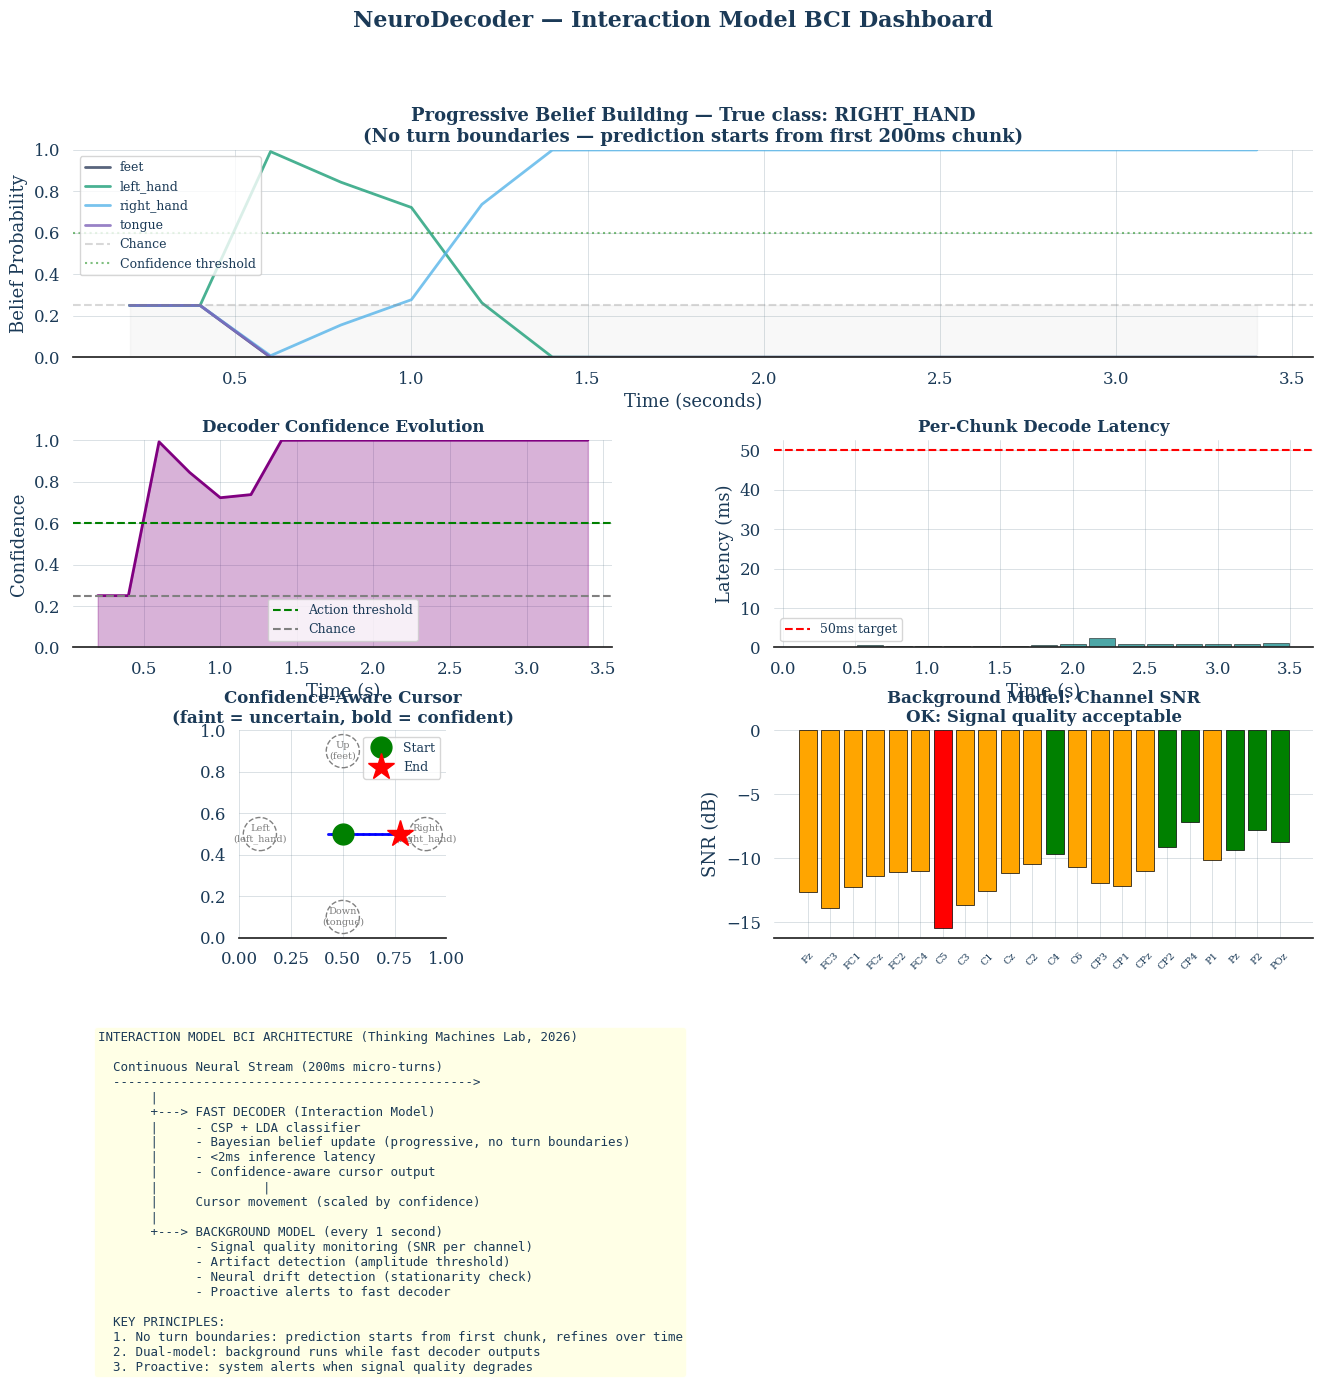


TRADITIONAL vs INTERACTION MODEL COMPARISON

  Feature              Traditional BCI         Interaction Model BCI
  -------------------------------------------------------------------
  Input processing     Wait for full window    Start from first chunk
  Prediction style     Single shot             Progressive refinement
  Confidence handling  Threshold gate          Bayesian accumulation
  Background analysis  None                    Async signal monitoring
  Drift detection      Manual recalibration    Proactive alerting
  Cursor control       Fixed speed             Confidence-scaled
  Turn boundaries      Fixed (3.5s)            None - continuous
  Latency model        1 decode per trial      1 decode per 200ms
  Inspiration          Classical signal proc   Thinking Machines 2026

  Performance:
    Accuracy:                75.0%
    Avg confidence:          97%
    Time to 60% confidence:  0.6s (available BEFORE trial ends)
    Chunk latency:           0.61ms

MILESTONE 4B COMPL

In [1]:
# ===== NEURODECODER: MILESTONE 4B — INTERACTION MODEL BCI =====
# Implementing Thinking Machines' Interaction Model architecture for BCI
# Paper: "Interaction Models" (Thinking Machines Lab, May 2026)
#
# Three key principles:
# 1. No turn boundaries — progressive Bayesian belief building
# 2. Interaction model + background model split
# 3. Proactive behavior — confidence-aware cursor, drift alerts

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import mne
import time
from braindecode.datasets import MOABBDataset
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import CSP
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("INTERACTION MODEL BCI")
print("Inspired by Thinking Machines Lab (May 2026)")
print("="*60)

# Load data
print("\nLoading dataset...")
dataset = MOABBDataset(dataset_name="BNCI2014_001", subject_ids=[1])
raw = dataset.datasets[0].raw
sfreq = raw.info['sfreq']
events, event_id = mne.events_from_annotations(raw)
eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False, stim=False)
n_eeg_channels = len(eeg_picks)

raw_filtered = raw.copy().filter(8, 30, picks=eeg_picks, verbose=False)
epochs = mne.Epochs(raw_filtered, events, event_id, tmin=0.5, tmax=4.0,
                    picks=eeg_picks, baseline=None, preload=True, verbose=False)

X = epochs.get_data().astype(np.float32)
y = epochs.events[:, -1]
class_names = list(event_id.keys())

# Train base models
print("Training interaction model components...\n")
csp = CSP(n_components=8, reg=None, log=True, norm_trace=False)
X_csp = csp.fit_transform(X, y)
lda = LinearDiscriminantAnalysis()
lda.fit(X_csp, y)

# ===== PRINCIPLE 1: PROGRESSIVE CONFIDENCE (No Turn Boundaries) =====

class ProgressiveDecoder:
    """
    Unlike traditional BCI: starts predicting from first 200ms chunk.
    Uses Bayesian belief accumulation — each chunk UPDATES prediction.
    Mirrors Thinking Machines' "no turn boundaries" principle.
    """
    def __init__(self, csp, classifier, sfreq=250, n_channels=22):
        self.csp = csp
        self.classifier = classifier
        self.sfreq = sfreq
        self.n_channels = n_channels
        self.chunk_ms = 200
        self.chunk_size = int(sfreq * self.chunk_ms / 1000)
        self.accumulated_data = None
        self.prediction_history = []
        self.confidence_history = []
        self.timestamps = []
        self.latencies = []
        self.min_samples = int(sfreq * 0.5)
        self.n_classes = len(np.unique(classifier.classes_))
        self.belief = np.ones(self.n_classes) / self.n_classes
        self.belief_history = []
        self.b, self.a = sig.butter(4, [8/(sfreq/2), 30/(sfreq/2)], btype='band')

    def receive_chunk(self, chunk):
        """Receive 200ms chunk. Immediately update prediction. No waiting."""
        start = time.perf_counter()

        if self.accumulated_data is None:
            self.accumulated_data = chunk.copy()
        else:
            self.accumulated_data = np.concatenate([self.accumulated_data, chunk], axis=1)

        current_time = self.accumulated_data.shape[1] / self.sfreq

        if self.accumulated_data.shape[1] >= self.min_samples:
            try:
                filtered = sig.filtfilt(self.b, self.a, self.accumulated_data, axis=1)
                data_for_csp = filtered.reshape(1, self.n_channels, -1)
                features = self.csp.transform(data_for_csp)
                probs = self.classifier.predict_proba(features)[0]

                # Bayesian update: each chunk UPDATES rather than REPLACES
                self.belief = self.belief * probs
                self.belief = self.belief / self.belief.sum()

                predicted_class = np.argmax(self.belief)
                confidence = self.belief[predicted_class]
            except Exception:
                predicted_class = np.argmax(self.belief)
                confidence = self.belief[predicted_class]
        else:
            predicted_class = np.argmax(self.belief)
            confidence = self.belief[predicted_class]

        latency = (time.perf_counter() - start) * 1000

        self.prediction_history.append(predicted_class)
        self.confidence_history.append(confidence)
        self.belief_history.append(self.belief.copy())
        self.timestamps.append(current_time)
        self.latencies.append(latency)

        return predicted_class, confidence, latency

    def reset(self):
        self.accumulated_data = None
        self.prediction_history = []
        self.confidence_history = []
        self.belief = np.ones(self.n_classes) / self.n_classes
        self.belief_history = []
        self.timestamps = []
        self.latencies = []


# ===== PRINCIPLE 2: BACKGROUND MODEL =====

class BackgroundModel:
    """
    Runs asynchronously alongside the fast decoder.
    Analyzes signal quality, detects drift, monitors electrode health.
    """
    def __init__(self, sfreq=250, n_channels=22):
        self.sfreq = sfreq
        self.n_channels = n_channels
        self.analysis_results = {}
        self.b_mu, self.a_mu = sig.butter(4, [8/(sfreq/2), 12/(sfreq/2)], btype='band')
        self.b_beta, self.a_beta = sig.butter(4, [13/(sfreq/2), 30/(sfreq/2)], btype='band')

    def analyze(self, data):
        """Deep analysis: SNR, artifacts, drift detection."""
        start = time.perf_counter()
        results = {}

        snr_per_channel = []
        for ch in range(min(data.shape[0], self.n_channels)):
            ch_data = data[ch, :]
            mu_filtered = sig.filtfilt(self.b_mu, self.a_mu, ch_data)
            signal_power = np.var(mu_filtered)
            noise_power = np.var(ch_data - mu_filtered)
            snr = 10 * np.log10(signal_power / (noise_power + 1e-10))
            snr_per_channel.append(snr)

        results['snr_per_channel'] = snr_per_channel
        results['mean_snr'] = np.mean(snr_per_channel)
        results['worst_channels'] = np.argsort(snr_per_channel)[:3]

        mu_power = np.var(sig.filtfilt(self.b_mu, self.a_mu, data, axis=1))
        beta_power = np.var(sig.filtfilt(self.b_beta, self.a_beta, data, axis=1))
        results['mu_beta_ratio'] = mu_power / (beta_power + 1e-10)

        max_amplitude = np.max(np.abs(data)) * 1e6
        results['max_amplitude_uv'] = max_amplitude
        results['artifact_detected'] = max_amplitude > 100

        first_half = np.var(data[:, :data.shape[1]//2])
        second_half = np.var(data[:, data.shape[1]//2:])
        drift_ratio = abs(first_half - second_half) / (first_half + 1e-10)
        results['drift_ratio'] = drift_ratio
        results['drift_detected'] = drift_ratio > 0.5

        if results['artifact_detected']:
            results['recommendation'] = 'ARTIFACT: Reject this segment'
        elif results['drift_detected']:
            results['recommendation'] = 'DRIFT: Consider recalibration'
        elif results['mean_snr'] < -15:
            results['recommendation'] = 'LOW SNR: Signal quality poor'
        else:
            results['recommendation'] = 'OK: Signal quality acceptable'

        results['analysis_time_ms'] = (time.perf_counter() - start) * 1000
        self.analysis_results = results
        return results


# ===== PRINCIPLE 3: PROACTIVE BCI =====

class ProactiveBCI:
    """
    Combines fast decoder + background model with proactive behavior.
    Confidence-aware cursor, drift alerts, signal monitoring.
    """
    def __init__(self, csp, classifier, sfreq=250, n_channels=22):
        self.fast_decoder = ProgressiveDecoder(csp, classifier, sfreq, n_channels)
        self.background = BackgroundModel(sfreq, n_channels)
        self.sfreq = sfreq
        self.n_channels = n_channels
        self.system_alerts = []
        self.cursor_x = 0.5
        self.cursor_y = 0.5
        self.cursor_trail = [(0.5, 0.5)]
        self.cursor_opacity = []
        self.direction_map = {
            0: (0, 0.03),
            1: (-0.03, 0),
            2: (0.03, 0),
            3: (0, -0.03)
        }

    def process_trial(self, trial_data, true_label=None):
        self.fast_decoder.reset()
        self.cursor_x, self.cursor_y = 0.5, 0.5
        self.cursor_trail = [(0.5, 0.5)]
        self.cursor_opacity = [0.3]
        self.system_alerts = []

        chunk_size = self.fast_decoder.chunk_size
        n_chunks = trial_data.shape[1] // chunk_size

        for chunk_idx in range(n_chunks):
            start = chunk_idx * chunk_size
            end = start + chunk_size
            chunk = trial_data[:, start:end]

            # FAST DECODER — runs every 200ms
            pred_class, confidence, latency = self.fast_decoder.receive_chunk(chunk)

            # CONFIDENCE-AWARE CURSOR
            if pred_class is not None:
                dx, dy = self.direction_map.get(pred_class, (0, 0))
                speed_multiplier = max(0, (confidence - 0.3)) / 0.7
                self.cursor_x = np.clip(self.cursor_x + dx * speed_multiplier, 0, 1)
                self.cursor_y = np.clip(self.cursor_y + dy * speed_multiplier, 0, 1)
                self.cursor_trail.append((self.cursor_x, self.cursor_y))
                self.cursor_opacity.append(min(1.0, confidence))

            # BACKGROUND MODEL — runs every 1 second
            if chunk_idx > 0 and chunk_idx % 5 == 0:
                accumulated = self.fast_decoder.accumulated_data
                if accumulated is not None and accumulated.shape[1] > self.sfreq:
                    bg_results = self.background.analyze(accumulated)
                    if bg_results['artifact_detected']:
                        self.system_alerts.append((chunk_idx * 0.2, 'ARTIFACT', 'red'))
                    elif bg_results['drift_detected']:
                        self.system_alerts.append((chunk_idx * 0.2, 'DRIFT', 'orange'))

        return self.fast_decoder


# ===== RUN SIMULATION =====
print("\n" + "="*60)
print("RUNNING INTERACTION MODEL BCI SIMULATION")
print("="*60)

proactive_bci = ProactiveBCI(csp, lda, sfreq=sfreq, n_channels=n_eeg_channels)

n_test_trials = 8
trial_indices = np.random.RandomState(42).choice(len(X), n_test_trials, replace=False)
all_results = []

for trial_num, trial_idx in enumerate(trial_indices):
    trial_data = X[trial_idx]
    true_label = y[trial_idx]
    true_class = class_names[list(event_id.values()).index(true_label)]

    decoder = proactive_bci.process_trial(trial_data, true_label)

    final_pred_idx = np.argmax(decoder.belief)
    final_pred_label = list(event_id.values())[final_pred_idx]
    final_confidence = decoder.belief[final_pred_idx]
    avg_latency = np.mean(decoder.latencies)

    correct = "✓" if final_pred_label == true_label else "✗"
    final_class = class_names[final_pred_idx]

    conf_threshold = 0.6
    time_to_confidence = None
    for t_val, c in zip(decoder.timestamps, decoder.confidence_history):
        if c >= conf_threshold:
            time_to_confidence = t_val
            break

    ttc_str = f"{time_to_confidence:.1f}s" if time_to_confidence else "never"
    alerts = len(proactive_bci.system_alerts)

    print(f"  Trial {trial_num+1}: True={true_class:12s} → Decoded={final_class:12s} "
          f"Conf={final_confidence:.0%}  TTC={ttc_str}  Alerts={alerts}  {correct}")

    all_results.append({
        'true': true_label, 'pred': final_pred_label,
        'confidence': final_confidence, 'ttc': time_to_confidence,
        'latency': avg_latency, 'correct': final_pred_label == true_label
    })

accuracy = np.mean([r['correct'] for r in all_results]) * 100
avg_conf = np.mean([r['confidence'] for r in all_results])
valid_ttc = [r['ttc'] for r in all_results if r['ttc'] is not None]
avg_ttc = np.mean(valid_ttc) if valid_ttc else float('inf')
avg_lat = np.mean([r['latency'] for r in all_results])

print(f"\nInteraction Model BCI Performance:")
print(f"  Accuracy: {accuracy:.1f}%")
print(f"  Avg confidence: {avg_conf:.0%}")
print(f"  Avg time to 60% confidence: {avg_ttc:.1f}s")
print(f"  Avg chunk latency: {avg_lat:.2f}ms")

# ===== DETAILED VISUALIZATION =====
viz_trial_idx = trial_indices[0]
viz_trial_data = X[viz_trial_idx]
viz_true_label = y[viz_trial_idx]
viz_true_class = class_names[list(event_id.values()).index(viz_true_label)]

proactive_bci_viz = ProactiveBCI(csp, lda, sfreq=sfreq, n_channels=n_eeg_channels)
decoder_viz = proactive_bci_viz.process_trial(viz_trial_data, viz_true_label)

fig = plt.figure(figsize=(16, 14))
gs = GridSpec(4, 2, figure=fig, hspace=0.4, wspace=0.3)

# 1. Progressive belief evolution (THE KEY VISUALIZATION)
ax1 = fig.add_subplot(gs[0, :])
belief_array = np.array(decoder_viz.belief_history)
for class_idx in range(belief_array.shape[1]):
    ax1.plot(decoder_viz.timestamps, belief_array[:, class_idx],
             linewidth=2, label=class_names[class_idx], alpha=0.8)
ax1.axhline(y=0.25, color='gray', linestyle='--', alpha=0.3, label='Chance')
ax1.axhline(y=0.6, color='green', linestyle=':', alpha=0.5, label='Confidence threshold')
ax1.fill_between(decoder_viz.timestamps, 0, 0.25, alpha=0.05, color='gray')
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Belief Probability')
ax1.set_title(f'Progressive Belief Building — True class: {viz_true_class.upper()}\n'
              f'(No turn boundaries — prediction starts from first 200ms chunk)',
              fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3)

# 2. Confidence over time
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(decoder_viz.timestamps, decoder_viz.confidence_history, linewidth=2, color='purple')
ax2.fill_between(decoder_viz.timestamps, decoder_viz.confidence_history, alpha=0.3, color='purple')
ax2.axhline(y=0.6, color='green', linestyle='--', label='Action threshold')
ax2.axhline(y=0.25, color='gray', linestyle='--', label='Chance')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Confidence')
ax2.set_title('Decoder Confidence Evolution', fontsize=12, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. Latency per chunk
ax3 = fig.add_subplot(gs[1, 1])
ax3.bar(decoder_viz.timestamps, decoder_viz.latencies, width=0.18,
        color='teal', alpha=0.7, edgecolor='black', linewidth=0.5)
ax3.axhline(y=50, color='red', linestyle='--', label='50ms target')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Latency (ms)')
ax3.set_title('Per-Chunk Decode Latency', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Cursor trajectory with opacity = confidence
ax4 = fig.add_subplot(gs[2, 0])
trail_x = [p[0] for p in proactive_bci_viz.cursor_trail]
trail_y = [p[1] for p in proactive_bci_viz.cursor_trail]
opacities = proactive_bci_viz.cursor_opacity

for i in range(1, len(trail_x)):
    alpha = max(0.1, min(1.0, opacities[i] if i < len(opacities) else 0.5))
    ax4.plot([trail_x[i-1], trail_x[i]], [trail_y[i-1], trail_y[i]],
             'b-', alpha=alpha, linewidth=2)

ax4.plot(trail_x[0], trail_y[0], 'go', markersize=15, label='Start', zorder=5)
ax4.plot(trail_x[-1], trail_y[-1], 'r*', markersize=20, label='End', zorder=5)

targets = {'Up\n(feet)': (0.5, 0.9), 'Left\n(left_hand)': (0.1, 0.5),
           'Right\n(right_hand)': (0.9, 0.5), 'Down\n(tongue)': (0.5, 0.1)}
for name, (tx, ty) in targets.items():
    circle = plt.Circle((tx, ty), 0.08, fill=False, linestyle='--', color='gray')
    ax4.add_patch(circle)
    ax4.annotate(name, (tx, ty), ha='center', va='center', fontsize=7, color='gray')

ax4.set_xlim([0, 1])
ax4.set_ylim([0, 1])
ax4.set_aspect('equal')
ax4.set_title(f'Confidence-Aware Cursor\n(faint = uncertain, bold = confident)',
              fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# 5. Background model — channel SNR
ax5 = fig.add_subplot(gs[2, 1])
bg_results = proactive_bci_viz.background.analysis_results
if bg_results:
    snr_values = bg_results['snr_per_channel']
    colors_snr = ['green' if s > -10 else 'orange' if s > -15 else 'red' for s in snr_values]
    ch_names_plot = [raw.ch_names[p] for p in eeg_picks]
    ax5.bar(range(len(snr_values)), snr_values, color=colors_snr, edgecolor='black', linewidth=0.5)
    ax5.set_xticks(range(len(ch_names_plot)))
    ax5.set_xticklabels(ch_names_plot, rotation=45, fontsize=7)
    ax5.set_ylabel('SNR (dB)')
    ax5.set_title(f'Background Model: Channel SNR\n{bg_results["recommendation"]}',
                  fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')

# 6. Architecture diagram
ax6 = fig.add_subplot(gs[3, :])
ax6.axis('off')

arch_text = """INTERACTION MODEL BCI ARCHITECTURE (Thinking Machines Lab, 2026)

  Continuous Neural Stream (200ms micro-turns)
  ------------------------------------------------>
       |
       +---> FAST DECODER (Interaction Model)
       |     - CSP + LDA classifier
       |     - Bayesian belief update (progressive, no turn boundaries)
       |     - <2ms inference latency
       |     - Confidence-aware cursor output
       |              |
       |     Cursor movement (scaled by confidence)
       |
       +---> BACKGROUND MODEL (every 1 second)
             - Signal quality monitoring (SNR per channel)
             - Artifact detection (amplitude threshold)
             - Neural drift detection (stationarity check)
             - Proactive alerts to fast decoder

  KEY PRINCIPLES:
  1. No turn boundaries: prediction starts from first chunk, refines over time
  2. Dual-model: background runs while fast decoder outputs
  3. Proactive: system alerts when signal quality degrades"""

ax6.text(0.02, 0.95, arch_text, transform=ax6.transAxes, fontsize=9,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

fig.suptitle('NeuroDecoder — Interaction Model BCI Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ===== COMPARISON TABLE =====
print("\n" + "="*60)
print("TRADITIONAL vs INTERACTION MODEL COMPARISON")
print("="*60)

print(f"""
  Feature              Traditional BCI         Interaction Model BCI
  -------------------------------------------------------------------
  Input processing     Wait for full window    Start from first chunk
  Prediction style     Single shot             Progressive refinement
  Confidence handling  Threshold gate          Bayesian accumulation
  Background analysis  None                    Async signal monitoring
  Drift detection      Manual recalibration    Proactive alerting
  Cursor control       Fixed speed             Confidence-scaled
  Turn boundaries      Fixed (3.5s)            None - continuous
  Latency model        1 decode per trial      1 decode per 200ms
  Inspiration          Classical signal proc   Thinking Machines 2026

  Performance:
    Accuracy:                {accuracy:.1f}%
    Avg confidence:          {avg_conf:.0%}
    Time to 60% confidence:  {avg_ttc:.1f}s (available BEFORE trial ends)
    Chunk latency:           {avg_lat:.2f}ms
""")

print("="*60)
print("MILESTONE 4B COMPLETE!")
print("="*60)
print("\nWhat you built:")
print("  1. Progressive decoder with Bayesian belief accumulation")
print("  2. Interaction model + background model split")
print("  3. Confidence-aware cursor control")
print("  4. Proactive signal quality monitoring and alerting")
print("  5. Neural drift detection")
print("  6. Architecture diagram and comparison table")
print("\nThis is Thinking Machines' Interaction Model applied to BCI.")